# Notebook for making templates from the hydrophone data

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wavfile
from scipy.signal import detrend,  butter, filtfilt
from scipy.signal import resample

### 1. Load the WAV file

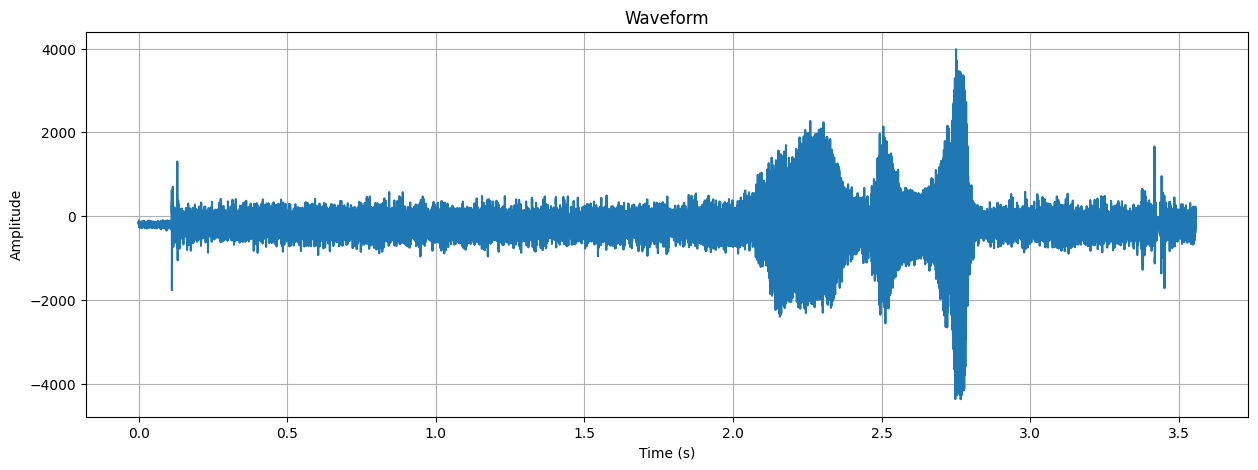

In [23]:
sample_rate, data = wavfile.read('sel.01.ch01.241119.110811.19.S01.J.wav')
# sample_rate, data = wavfile.read('/home/sjuber/2024-11-09_13.49.00_to_13.49.30.wav') 
# sample_rate, data = wavfile.read('2024-11-09_13.49.00_to_13.49.30.wav') 
#sample_rate, data = wavfile.read('/home/sjuber/5s_100Hz_tone.wav')

# # pick one channel
# if data.ndim > 1:
#     data = data[:, 1] 

# Create a time array
times = np.arange(len(data)) / sample_rate

# Plot the waveform
plt.figure(figsize=(15, 5))
plt.plot(times, data)
plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid()
plt.show()

## 2. Plot the spectrogram 

In [45]:
f1 = 450
f2 = 990

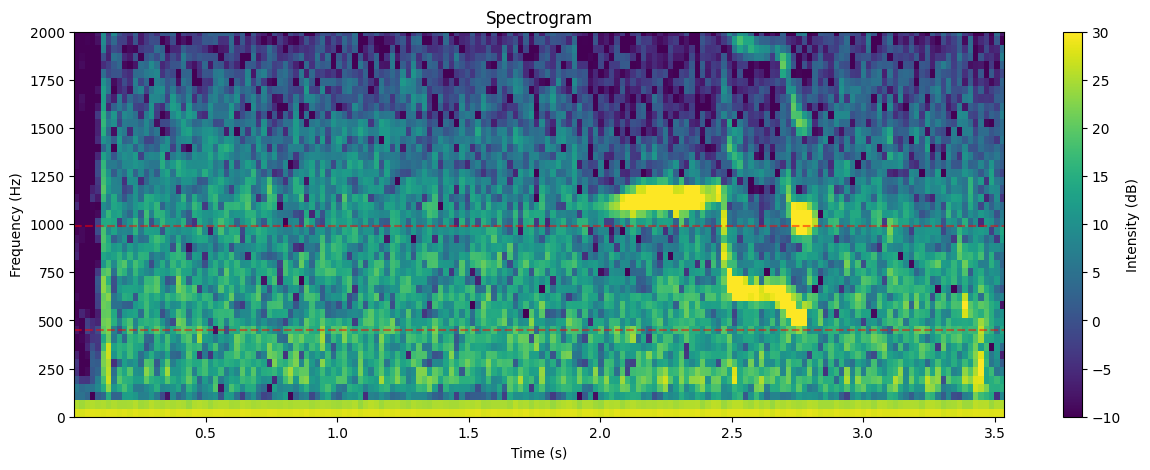

In [46]:
plt.figure(figsize=(15, 5))
plt.specgram(data, Fs=sample_rate,scale='dB',vmin=-10,vmax=30,NFFT=1024)
plt.title('Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Intensity (dB)')
plt.ylim(0, 2000)
# plt.xlim([10,20])
plt.plot(plt.xlim(), [f1,f1], 'r--', alpha=0.5)
plt.plot(plt.xlim(), [f2,f2], 'r--', alpha=0.5)
# plt.xlim(times[0], times[-1])
plt.show()

### 3. Resample the hydrophone data to the same 2 kHz sample rate as the DAS

Sample Rate: 44100 Hz


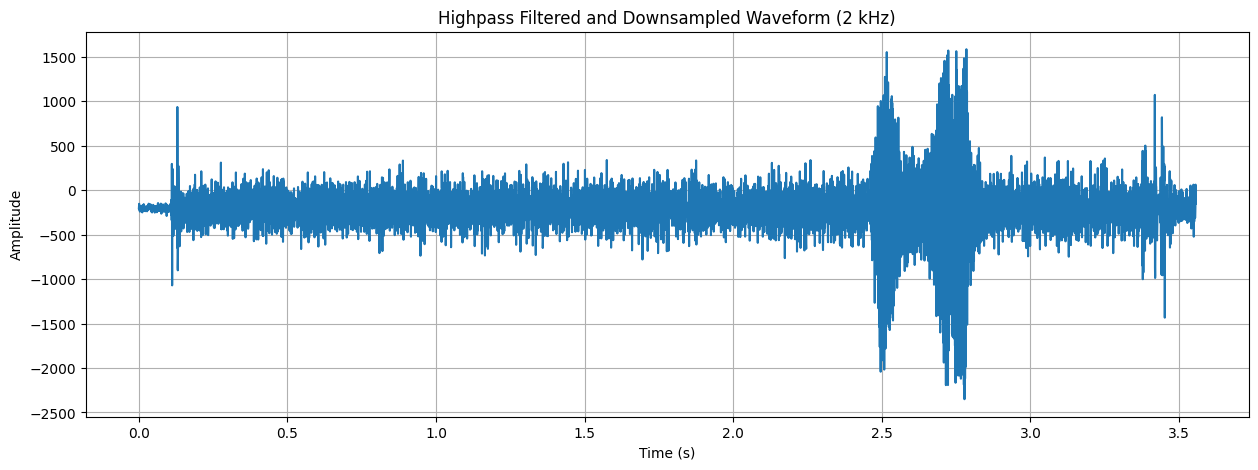

In [36]:
print(f"Sample Rate: {sample_rate} Hz")

# Downsample windowed_data to 2 kHz


target_rate = 2000  # Hz
#target_rate = 4000  # Hz
number_of_samples = int(len(data) * target_rate / sample_rate)
#number_of_samples = int(len(windowed_data)) 


# Resample the data
downsampled_data = resample(data, number_of_samples)
#downsampled_data = decimate(windowed_data, q=22,  ftype='fir', zero_phase=True)

# Update the times array
#downsampled_times = np.linspace(times[0], times[-1], number_of_samples)
downsampled_times = np.arange(len(downsampled_data)) / target_rate


# Plot the downsampled waveform
plt.figure(figsize=(15, 5))
plt.plot(downsampled_times, downsampled_data)
plt.title('Highpass Filtered and Downsampled Waveform (2 kHz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
#plt.xlim(downsampled_times[0], downsampled_times[-1])
plt.grid()
plt.show()


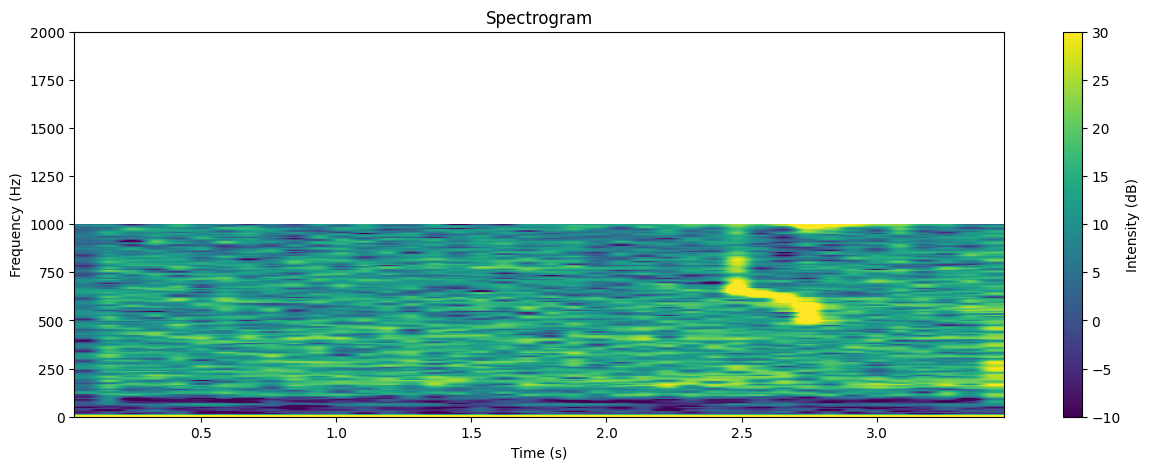

In [38]:
plt.figure(figsize=(15, 5))
plt.specgram(downsampled_data, Fs=target_rate,NFFT=300,scale='dB',vmin=-10,vmax=30)
plt.title('Spectrogram')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.colorbar(label='Intensity (dB)')
plt.ylim(0, 2000)
# plt.xlim([10,20])
# plt.plot([10, 20], [f1,f1], 'r--', alpha=0.5)
# plt.plot([10, 20], [f2,f2], 'r--', alpha=0.5)
# plt.xlim(times[0], times[-1])
plt.show()

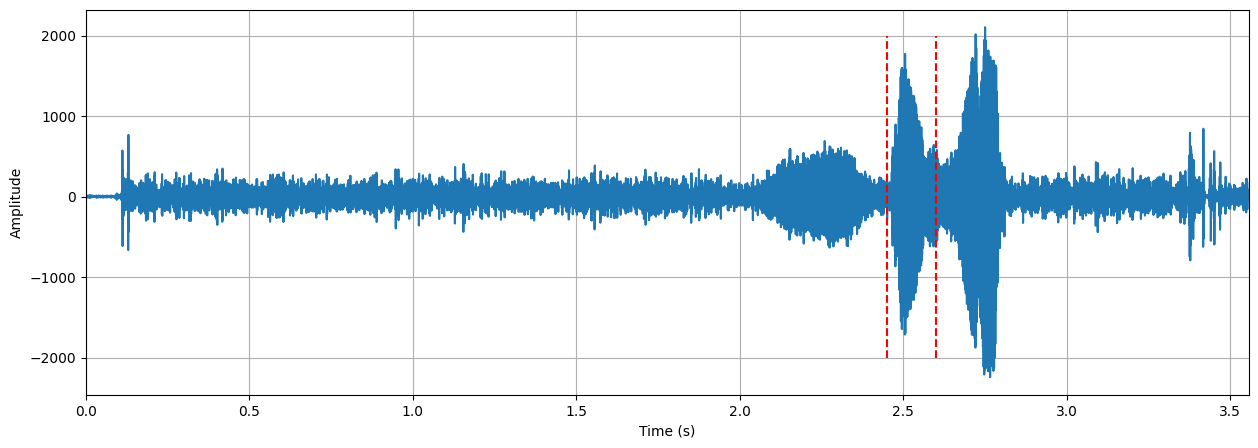

In [59]:
# Apply a high-pass filter above 100 Hz


# Design the filter
nyquist = 0.5 * sample_rate
# cutoff = 700  # Hz
#cutoff = 50  # Hz
# normal_cutoff = cutoff / nyquist
b, a = butter(2, [f1,f2], 'bandpass', fs=sample_rate)

# Apply the filter
filtered_data = filtfilt(b, a, data, axis=0)

# Plot the filtered waveform
plt.figure(figsize=(15, 5))
plt.plot(times, filtered_data) ##if multi-channel
#plt.plot(times, windowed_data)
# plt.title(f'Highpass Filtered Waveform (>{cutoff} Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.xlim(times[0], times[-1])
t0 = 2.45
# t1 = 2.85
t1=2.6
# plt.xlim(10,20)
plt.plot(t0*np.ones(2), [-2000, 2000], 'r--', label='t0')
plt.plot(t1*np.ones(2), [-2000, 2000], 'r--', label='t1')
# plt.ylim([-1000, 1000])
#plt.ylim([-1, 1])
plt.grid()
plt.show()


### 4. Window the data

6615


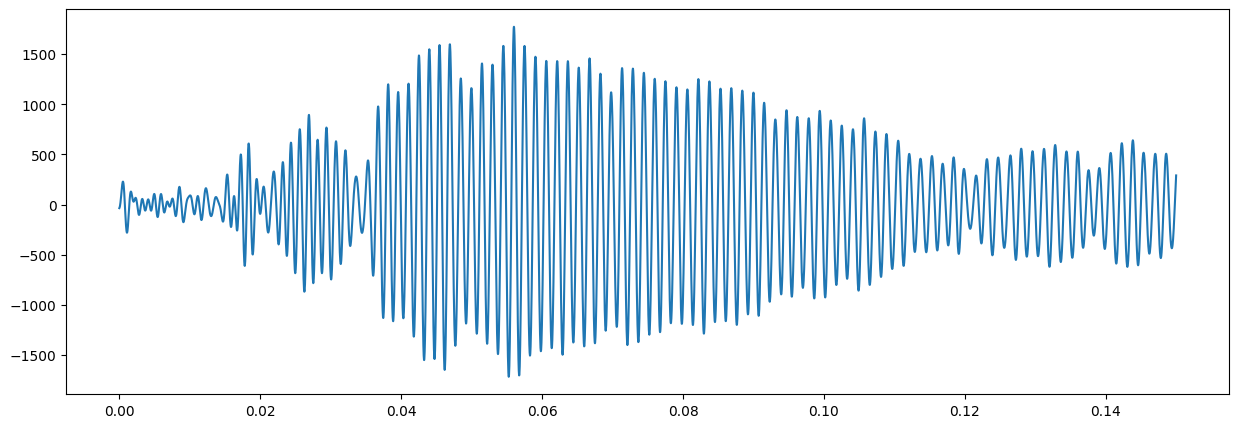

In [60]:

windowed_data = filtered_data[int(t0*sample_rate):int(t1*sample_rate)]
windowed_times = np.arange(len(windowed_data)) / sample_rate
# Plot the windowed waveform
plt.figure(figsize=(15, 5))
plt.plot(windowed_times, windowed_data) ##if multi-channel

print(len(windowed_data))

In [61]:
# Save the template (windowed, filtered, and downsampled) to a npz file
np.savez('template.npz', data=windowed_data, time=windowed_times)

In [63]:
windowed_times[-1] * 2000

299.9546485260771